# Tier 12b: fixed off-the-shelf turboshafts, battery-assisted hover, in-flight recharge

These are design rules the user set on 2026-10-03:

- **Power available is a hard limit.** Turbine power required can never
  exceed it.
- **The engines are fixed.** As a non-OEM there is little to gain in turbine
  power, so each turboshaft is the user's 1,120 hp deck engine. It lapses
  with altitude (XV-15 fit).
- **The battery fills the gap.** It supplements the turbines in hover and is
  recharged by the generators in flight.
- **The aircraft is sized around the engines.** If that means downsizing,
  so be it.

**Implementation.**

- `HaloAssumptions.power_rated_turboshaft_fixed_W` is 1,120 hp; None
  restores a sized engine.
- `build_mission(..., hybridization_electric_min=-1)` allows negative battery
  shares (recharge) within the charge rating. SOC stays inside the battery
  window at every segment end.
- `solve_halo_sizing(objective="payload")` maximizes payload around the
  fixed engines.

```powershell
uv run jupyter lab notebooks/tier12_fixed_engines
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_tier12, requirements_tier10c,
                                  solve_halo_sizing)

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Can the fixed engines meet 250 kt?

The trade comes from continuation in the max-speed requirement: maximize
payload at 445 nm, 13,000 ft ceiling and OGE hover at 4,000 ft, each speed
warm-started from the previous one.

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


180 kt: max payload   1240 kg, take-off  17,509 lb


190 kt: max payload   1240 kg, take-off  17,509 lb


200 kt: max payload   1240 kg, take-off  17,509 lb


205 kt: max payload   1186 kg, take-off  16,875 lb


...

225 kt: max payload    163 kg, take-off  10,935 lb


CasADi - 2026-10-03 10:12:16 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 181, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-03 10:12:19 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 181, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-03 10:12:34 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 115, col 0).") [.../casadi/core/oracle_function.cpp:408]


230 kt: no closed design (payload would be negative)
PASS  max payload falls as max speed rises beyond the climb-limited plateau
PASS  250 kt is infeasible with 2 x 1,120 hp at any size
PASS  about 900 kg is achievable at 210 kt
binding at 180 kt: climb: turboshaft power_shaft_W, climb: generator power_shaft_W
PASS  below ~205 kt the 1,500 ft/min climb (turbines alone) limits payload, not max speed


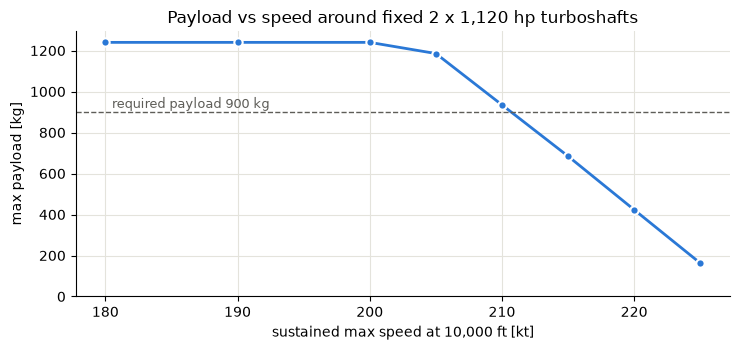

In [2]:
trade, previous = [], solve_halo_sizing(requirements=replace(HaloRequirements(), velocity_max_m_s=180 * u.knot),
                                        objective="payload")
for knots in (180, 190, 200, 205, 210, 215, 220, 225, 230):
    try:
        previous = solve_halo_sizing(requirements=replace(HaloRequirements(), velocity_max_m_s=knots * u.knot),
                                     objective="payload", initial=previous)
        trade.append((knots, previous.mass_payload_kg, previous.mass_takeoff_kg, previous.binding))
        print(f"{knots} kt: max payload {previous.mass_payload_kg:6.0f} kg, take-off {previous.mass_takeoff_kg / u.lbm:7,.0f} lb")
    except RuntimeError:
        print(f"{knots} kt: no closed design (payload would be negative)")
        break
speeds = np.array([t[0] for t in trade]); payloads = np.array([t[1] for t in trade])
check("max payload falls as max speed rises beyond the climb-limited plateau", np.all(np.diff(payloads[speeds >= 205]) < 0))
check("250 kt is infeasible with 2 x 1,120 hp at any size", trade[-1][0] < 250)
check("about 900 kg is achievable at 210 kt", dict((t[0], t[1]) for t in trade)[210] >= 900)
plateau = trade[0][3]
print("binding at 180 kt:", ", ".join(b for b in plateau if "climb" in b or "max_speed" in b))
check("below ~205 kt the 1,500 ft/min climb (turbines alone) limits payload, not max speed",
      any("climb: turboshaft" in b for b in plateau))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(speeds, payloads, color=blue, lw=2, marker="o", ms=6, mec="white", mew=1.5)
ax.axhline(900, color=ink_muted, lw=1, ls="--")
ax.text(speeds[0] + 0.5, 920, "required payload 900 kg", color=ink_muted, fontsize=9)
ax.set(xlabel="sustained max speed at 10,000 ft [kt]", ylabel="max payload [kg]", ylim=(0, None),
       title="Payload vs speed around fixed 2 x 1,120 hp turboshafts")
plt.tight_layout()
plt.show()

## 2. Reference: 900 kg at 210 kt

This is the provisional reference, pending the user's choice of speed and
payload.

take-off 6,748 kg = 14,877 lb; empty 4,829 kg; fuel 1,019 kg
turboshafts 2 x 1,120 hp (fixed); generators 2 x 716 kW; motors 2 x 812 kW; battery 67 kWh / 799 kW
binding: max_speed: turboshaft power_shaft_W, engine-out hover: generator power_shaft_W, hover: motor power_shaft_W, hover: gearbox power_input_W, hover: propulsor power_shaft_W, climb: generator power_shaft_W, engine-out hover: battery discharge_power_W, soc_after_engine_out_hover, static_margin, cn_beta_per_rad, soc_end
PASS  turboshaft rating is the fixed deck engine
PASS  every constraint satisfied (turbine power required <= available everywhere)
PASS  the turbines size the airframe through the speed requirement
  take-off hover  battery share +0.27  SOC end 0.850  rotors  1,378 kW
  climb           battery share -0.04  SOC end 0.950  rotors  1,126 kW
  cruise          battery share +0.02  SOC end 0.300  rotors    712 kW
  reserve loiter  battery share -0.00  SOC end 0.300  rotors    542 kW
  descent         battery share -

Tier 12 (sized engines, 250 kt): 17,227 lb; Tier 12b: 14,877 lb
PASS  Tier 12 baseline still reproduces 17,228 lb


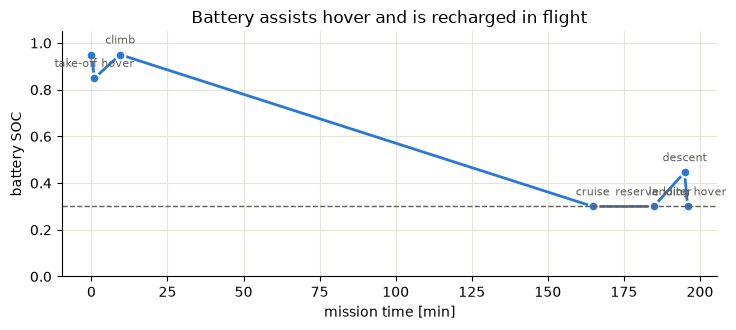

In [3]:
r = solve_halo_sizing()
d = r.design
print(f"take-off {r.mass_takeoff_kg:,.0f} kg = {r.mass_takeoff_kg / u.lbm:,.0f} lb; empty {r.mass_empty_kg:,.0f} kg; fuel {r.mass_fuel_kg:,.0f} kg")
print(f"turboshafts 2 x {d.power_rated_turboshaft_W / u.hp:,.0f} hp (fixed); generators 2 x {r.power_rated_generator_W / 1e3:,.0f} kW; "
      f"motors 2 x {r.power_rated_motor_W / 1e3:,.0f} kW; battery {r.energy_battery_kWh:.0f} kWh / {d.power_max_discharge_battery_W / 1e3:,.0f} kW")
print("binding:", ", ".join(r.binding))
check("turboshaft rating is the fixed deck engine", d.power_rated_turboshaft_W == 1120 * u.hp)
check("every constraint satisfied (turbine power required <= available everywhere)", r.min_margin > -1e-6)
check("the turbines size the airframe through the speed requirement", "max_speed: turboshaft power_shaft_W" in r.binding)
for s in r.segments:
    print(f"  {s['label']:<15} battery share {s['hybridization']:+.2f}  SOC end {s['soc_end']:.3f}  rotors {s['power_rotors_W'] / 1e3:6,.0f} kW")
shares = {s["label"]: s["hybridization"] for s in r.segments}
check("battery supplements both hovers", shares["take-off hover"] > 0.05 and shares["landing hover"] > 0.05)
check("generators recharge the battery in flight", any(v < -0.01 for v in shares.values()))
check("SOC holds the 0.30 reserve floor at every segment end (engine-out reserve always available)",
      all(0.3 - 1e-6 <= s["soc_end"] <= 0.95 + 1e-6 for s in r.segments))

tier12 = solve_halo_sizing(requirements=requirements_tier10c, assumptions=assumptions_tier12)
print(f"Tier 12 (sized engines, 250 kt): {tier12.mass_takeoff_kg / u.lbm:,.0f} lb; Tier 12b: {r.mass_takeoff_kg / u.lbm:,.0f} lb")
check("Tier 12 baseline still reproduces 17,228 lb", abs(tier12.mass_takeoff_kg / u.lbm - 17228) < 5)

t = np.cumsum([0] + [s["duration_s"] / 60 for s in r.segments])
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(t, [0.95] + [s["soc_end"] for s in r.segments], color=blue, lw=2, marker="o", ms=7, mec="white", mew=1.5)
for x, s in zip(t[1:], r.segments):
    ax.annotate(s["label"], (x, s["soc_end"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, color=ink_muted)
ax.axhline(0.3, color=ink_muted, lw=1, ls="--")
ax.set(xlabel="mission time [min]", ylabel="battery SOC", ylim=(0, 1.05), title="Battery assists hover and is recharged in flight")
plt.tight_layout()
plt.show()

## 3. Reading the result

- **The engines can't reach 250 kt.** With fixed 1,120 hp engines, 250 kt
  is out of reach: payload reaches zero near 228 kt. Shrinking the aircraft
  helps less than expected, because the fuselage stays at XV-15 size and its
  drag doesn't shrink. Sizing the fuselage from payload is a Tier 22
  freed trade.
- **The battery takes the hover peaks.** It covers about a quarter of
  take-off hover and half of landing hover. The generators recharge it in
  climb and descent, and cruise draws it down. Turbine power required never
  exceeds power available.
- **What the user needs to decide:** the speed/payload pair. 900 kg at
  210 kt is the provisional reference.

## 4. Summary and unit test suite

In [4]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

11 / 11 notebook checks passed


In [5]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 264 tests in 23.469s

OK
